In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np


In [7]:

data = pd.read_csv('/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/template_project/data/Data_Collection13_02_2025/all_apps_wide-2025-02-13.csv')


In [8]:
data["participant.label"]


0     GK032w6A
1     xok4JQIx
2     HiSs6lVk
3     u874W2aM
4     QfM0ZFNw
5     nxmyIOpw
6     ezgUFdcT
7     C2br7Phv
8     3yK1oFK6
9     vACvFycz
10    cRiCPXCE
11    JNYrO34l
12    HrbOnpyN
13    zH1knbha
14    qEfvearh
15    agyQigoU
Name: participant.label, dtype: object

In [9]:
data["bargain_live.1.player.amount_proposed_list"]

0                                       [7.00000000001]
1         [5.00000000001, 9.00000000001, 7.00000000001]
2                                      [35.00000000001]
3                                      [30.00000000001]
4                                      [22.00000000001]
5                                                    []
6     [31.00000000001, 41.00000000001, 19.0000000000...
7                      [26.00000000001, 18.00000000001]
8     [20.00000000001, 20.00000000001, 41.0000000000...
9                                      [36.00000000001]
10                                     [42.00000000001]
11     [27.00000000001, 56.00000000001, 15.00000000001]
12                                     [28.00000000001]
13                                      [9.00000000001]
14                                     [36.00000000001]
15     [30.00000000001, 13.00000000001, 17.00000000001]
Name: bargain_live.1.player.amount_proposed_list, dtype: object

In [10]:
# # Initialize counters
# all_offers = []
# below_valuation_count = 0

# # Loop through each round and extract offers and valuations
# for i in range(3, 34):  # Assuming rounds go from 3 to 33
#     offer_column = f'bargain_live.{i}.player.amount_proposed_list'
#     valuation_column = f'bargain_live.{i}.player.valuation'
    
#     if offer_column in data.columns and valuation_column in data.columns:
#         # Extract offers for buyers
#         buyer_offers = data.loc[buyers, offer_column].dropna()

#         # Ensure offers are properly parsed from string lists
#         buyer_offers = buyer_offers.apply(lambda x: eval(x) if isinstance(x, str) else x)  # Convert string lists to actual lists
#         buyer_offers = buyer_offers.explode()  # Convert list-like values into separate rows
#         buyer_offers = pd.to_numeric(buyer_offers, errors='coerce').dropna()  # Convert to numeric

#         # Extract valuations for buyers
#         buyer_valuations = data.loc[buyers, valuation_column].dropna()
#         buyer_valuations = pd.to_numeric(buyer_valuations, errors='coerce')  # Convert to numeric
        
#         # Count offers below valuation
#         for buyer in buyers:
#             if buyer in buyer_valuations.index:
#                 valuation = buyer_valuations.loc[buyer]
#                 below_valuation_count += (buyer_offers < valuation).sum()  # FIXED LINE

#         # Store all offers
#         all_offers.extend(buyer_offers.tolist())

# # Total number of offers
# total_offers = len(all_offers)

# # Display results
# print(f"Total number of offers made by buyers: {total_offers}")
# print(f"Number of offers below valuation: {below_valuation_count}")


# Descriptives: What were the Rules (i.e. Termination times, TA costs)

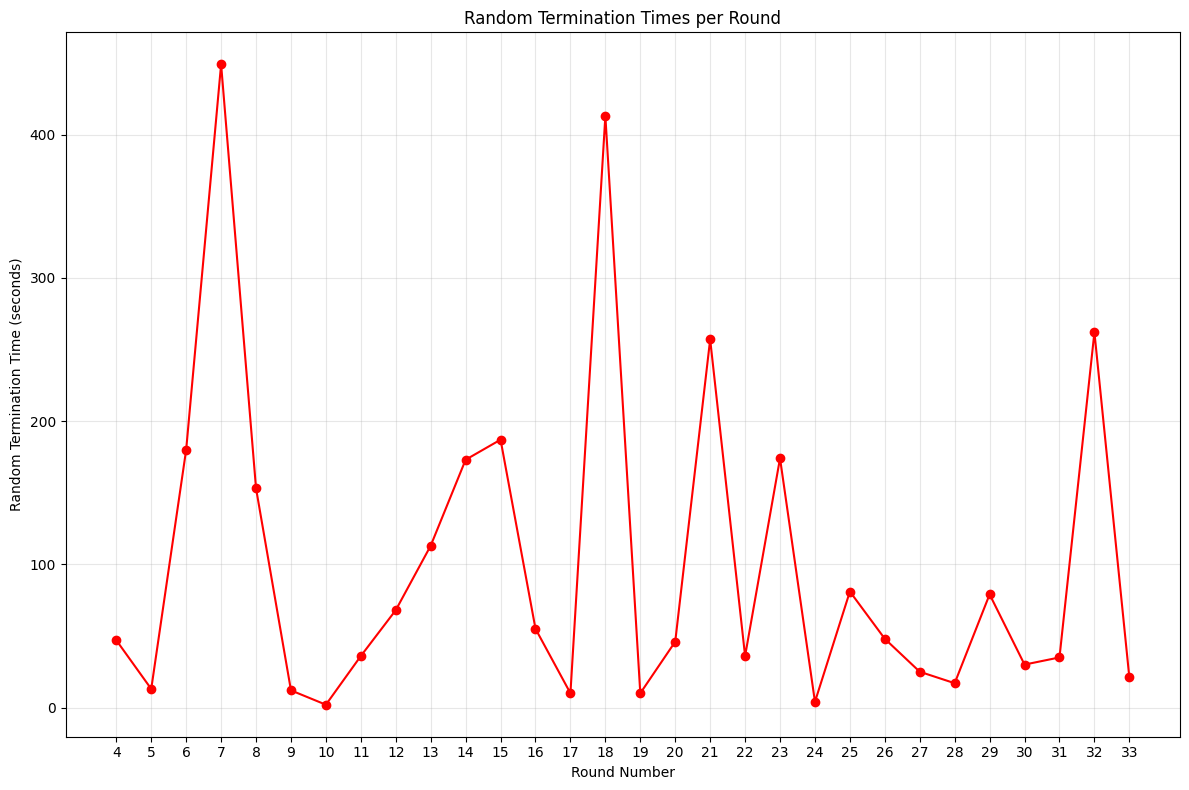

In [11]:
# Create list to store termination times
termination_times = []
rounds = []

# Get termination times for each round
for i in range(4, 34):
    time = data[f'bargain_live.{i}.group.random_termination_time_current_round'].iloc[0]
    termination_times.append(time)
    rounds.append(i)

# Create figure
plt.figure(figsize=(12, 8))

# Plot termination times
plt.plot(rounds, termination_times, marker='o', color='red', linestyle='-')
plt.xlabel('Round Number')
plt.ylabel('Random Termination Time (seconds)')
plt.title('Random Termination Times per Round')
plt.grid(True, alpha=0.3)

# Set x-axis ticks to show all round numbers
plt.xticks(rounds)

plt.tight_layout()
plt.show()

In [12]:
data['bargain_live.7.player.valuation']

0     34.0
1     34.0
2      0.0
3     14.0
4      0.0
5     14.0
6     21.0
7      0.0
8      0.0
9      0.0
10    45.0
11    21.0
12     0.0
13    45.0
14     0.0
15     0.0
Name: bargain_live.7.player.valuation, dtype: float64

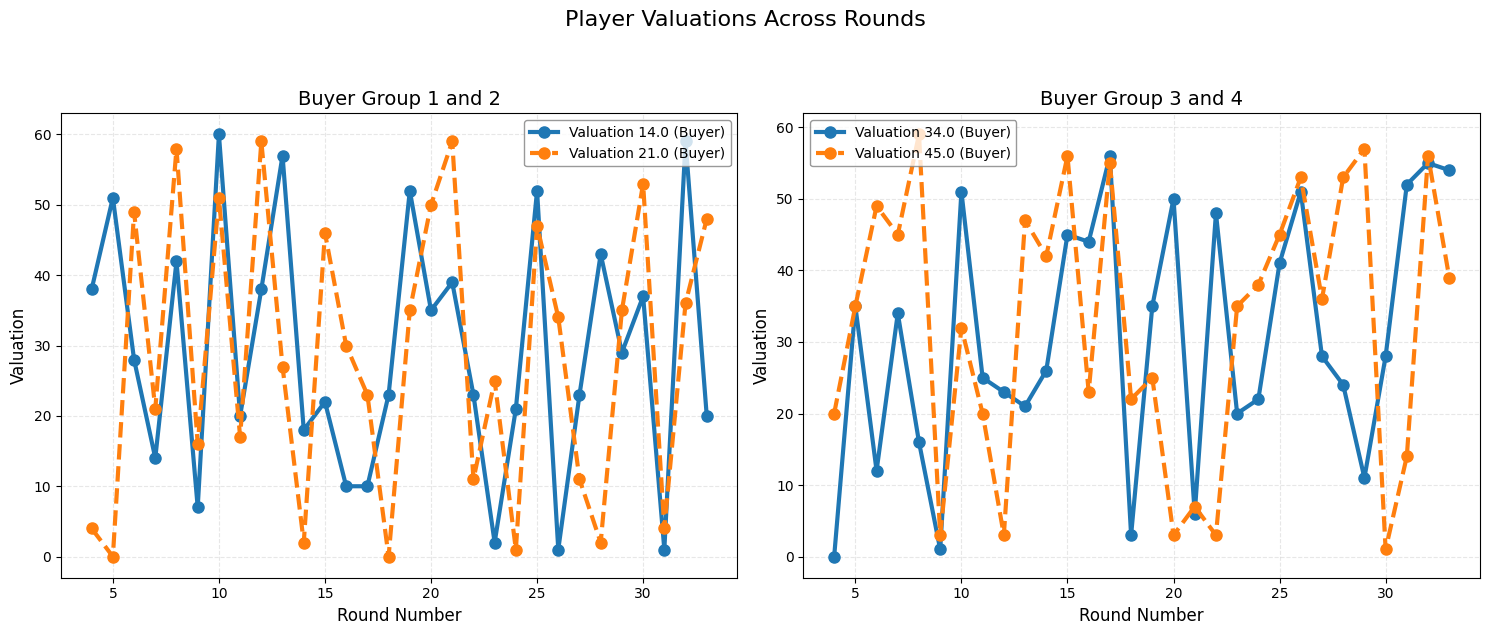

In [13]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Dictionary to store unique valuation patterns
unique_valuations = {}

# Get players with non-zero valuations in round 7
non_zero_players = data.index[data['bargain_live.7.player.valuation'] > 0]

# First, identify unique valuation patterns
for player in non_zero_players:
    val_round_7 = data.loc[player, 'bargain_live.7.player.valuation']
    if val_round_7 not in unique_valuations:
        valuations = []
        for round_num in range(4, 34):
            val = data.loc[player, f'bargain_live.{round_num}.player.valuation']
            valuations.append(val)
        unique_valuations[val_round_7] = {
            'valuations': valuations,
            'role': data.loc[player, 'participant.role_in_game']
        }

# Sort valuations
sorted_valuations = sorted(unique_valuations.items())

# Styles for each subplot
styles = [
    {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 3},    # Solid blue
    {'color': '#ff7f0e', 'linestyle': '--', 'linewidth': 3},   # Dashed orange
]

# Plot first two valuations (lower values) in first subplot
for i, (initial_val, data_dict) in enumerate(sorted_valuations[:2]):
    style = styles[i]
    ax1.plot(range(4, 34), data_dict['valuations'], 
            marker='o', markersize=8,
            label=f'Valuation {initial_val} ({data_dict["role"]})',
            **style)

# Plot second two valuations (higher values) in second subplot
for i, (initial_val, data_dict) in enumerate(sorted_valuations[2:]):
    style = styles[i]
    ax2.plot(range(4, 34), data_dict['valuations'], 
            marker='o', markersize=8,
            label=f'Valuation {initial_val} ({data_dict["role"]})',
            **style)

# Configure first subplot
ax1.set_xlabel('Round Number', fontsize=12)
ax1.set_ylabel('Valuation', fontsize=12)
ax1.set_title('Buyer Group 1 and 2', fontsize=14)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')

# Configure second subplot
ax2.set_xlabel('Round Number', fontsize=12)
ax2.set_ylabel('Valuation', fontsize=12)
ax2.set_title('Buyer Group 3 and 4', fontsize=14)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')

# Add main title
fig.suptitle('Player Valuations Across Rounds', fontsize=16, y=1.05)

# Adjust layout
plt.tight_layout()
plt.show()

# Now, lets get into player behaviour

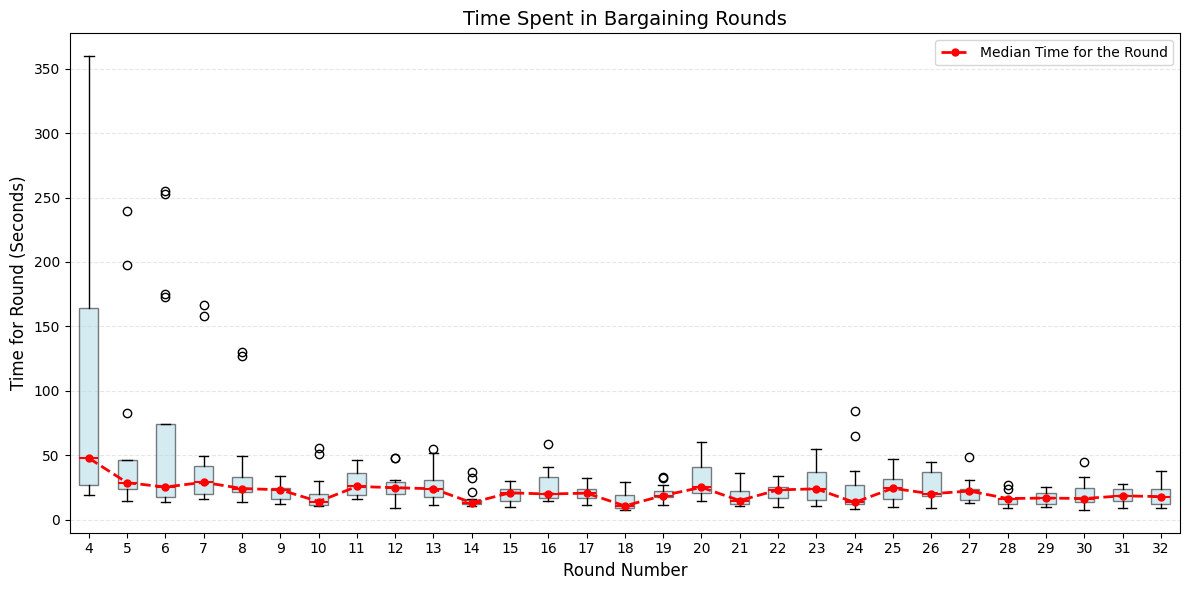


Median times for each round (in seconds):
Round 4 to 5: 47.75 seconds
Round 5 to 6: 28.70 seconds
Round 6 to 7: 25.33 seconds
Round 7 to 8: 29.01 seconds
Round 8 to 9: 24.17 seconds
Round 9 to 10: 23.19 seconds
Round 10 to 11: 14.09 seconds
Round 11 to 12: 25.75 seconds
Round 12 to 13: 24.84 seconds
Round 13 to 14: 23.95 seconds
Round 14 to 15: 13.23 seconds
Round 15 to 16: 20.84 seconds
Round 16 to 17: 19.90 seconds
Round 17 to 18: 20.60 seconds
Round 18 to 19: 10.69 seconds
Round 19 to 20: 18.75 seconds
Round 20 to 21: 25.09 seconds
Round 21 to 22: 14.81 seconds
Round 22 to 23: 23.12 seconds
Round 23 to 24: 23.93 seconds
Round 24 to 25: 13.37 seconds
Round 25 to 26: 24.33 seconds
Round 26 to 27: 20.08 seconds
Round 27 to 28: 22.23 seconds
Round 28 to 29: 16.39 seconds
Round 29 to 30: 16.77 seconds
Round 30 to 31: 16.42 seconds
Round 31 to 32: 18.50 seconds
Round 32 to 33: 17.90 seconds

Overall median time across all rounds: 20.95 seconds


In [14]:
# Create list to store time differences between rounds
time_differences = []
round_pairs = []

for i in range(4, 33):  # We'll calculate differences between rounds 4-5 up to 32-33
    # Get start times for current and next round
    current_round_times = pd.to_datetime(data[f'bargain_live.{i}.group.bargain_start_time'])
    next_round_times = pd.to_datetime(data[f'bargain_live.{i+1}.group.bargain_start_time'])
    
    # Calculate time differences in seconds
    differences = (next_round_times - current_round_times).dt.total_seconds()
    time_differences.append(differences)
    round_pairs.append(i)  # Just store the first round number

# Create figure
plt.figure(figsize=(12, 6))

# Create boxplot
plt.boxplot(time_differences, 
            patch_artist=True,  # Fill boxes with color
            boxprops=dict(facecolor='lightblue', alpha=0.5),
            medianprops=dict(color="red", linewidth=1.5))

# Calculate and plot median line
medians = [np.median(diff) for diff in time_differences]
plt.plot(range(1, len(medians) + 1), medians, 
         color='red', marker='o', linestyle='--', 
         linewidth=2, markersize=5, 
         label='Median Time for the Round')

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Time for Round (Seconds)', fontsize=12)
plt.title('Time Spent in Bargaining Rounds', fontsize=14)

# Set x-axis labels to show round numbers
plt.xticks(range(1, len(round_pairs) + 1), round_pairs)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add legend
plt.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Calculate median times for each round
median_times = [np.median(diff) for diff in time_differences]

print("\nMedian times for each round (in seconds):")
for round_num, median in zip(round_pairs, median_times):
    print(f"Round {round_num} to {round_num+1}: {median:.2f} seconds")

# Calculate overall median
overall_median = np.median([item for sublist in time_differences for item in sublist])
print(f"\nOverall median time across all rounds: {overall_median:.2f} seconds")


Correlation coefficient between duration and valuation: 0.018

Summary Statistics by Valuation Quartile:
                      mean        std  count
Valuation_Group                             
Q1 (Lowest)      29.392801  28.815193     58
Q2               29.248609  29.813609     56
Q3               26.005483   9.529185     56
Q4 (Highest)     32.210798  39.836535     56


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_11028/484376587.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = df.groupby('Valuation_Group')['Duration'].agg(['mean', 'std', 'count'])


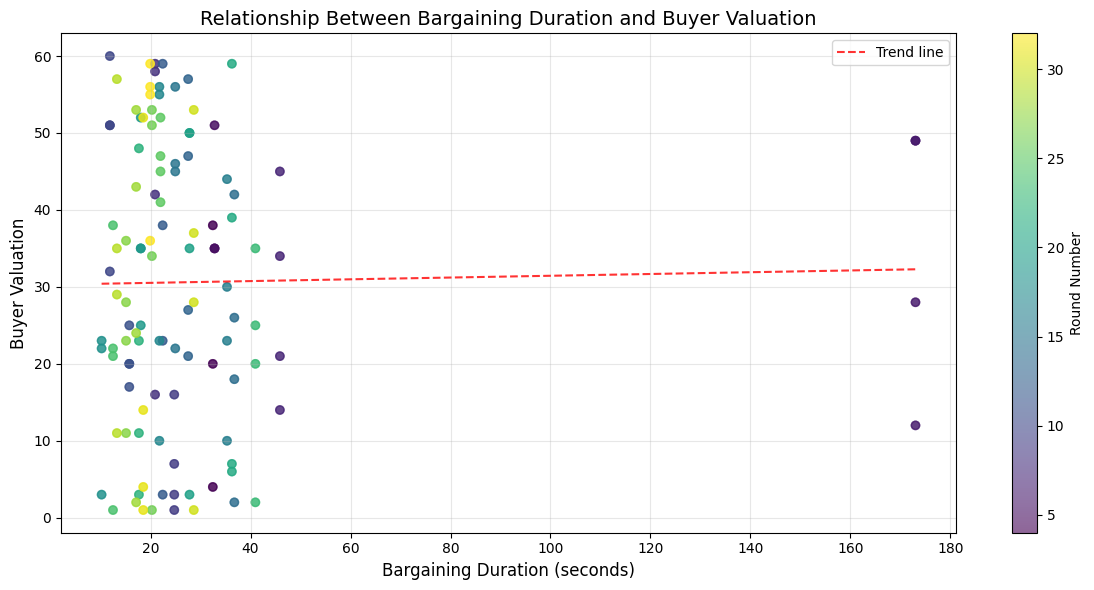

In [15]:
# Create lists to store durations and valuations
durations = []
valuations = []
rounds = []

for i in range(4, 33):
    # Get start times for the round
    start_times = pd.to_datetime(data[f'bargain_live.{i}.group.bargain_start_time'])
    next_round_times = pd.to_datetime(data[f'bargain_live.{i+1}.group.bargain_start_time'])
    
    # Calculate duration in seconds
    round_durations = (next_round_times - start_times).dt.total_seconds()
    
    # Get buyers and their valuations for this round
    buyers = data[data['participant.role_in_game'] == 'Buyer'].index
    for buyer in buyers:
        valuation = data.loc[buyer, f'bargain_live.{i}.player.valuation']
        if valuation > 0:  # Only consider active buyers
            durations.append(round_durations.iloc[0])  # Use first duration since they're all the same for the round
            valuations.append(valuation)
            rounds.append(i)

# Create scatter plot
plt.figure(figsize=(12, 6))

# Create scatter plot with color intensity based on round number
scatter = plt.scatter(durations, valuations, 
                     c=rounds, cmap='viridis', 
                     alpha=0.6)

# Add trend line
z = np.polyfit(durations, valuations, 1)
p = np.poly1d(z)
plt.plot(sorted(durations), p(sorted(durations)), 
         "r--", alpha=0.8, label=f'Trend line')

# Add labels and title
plt.xlabel('Bargaining Duration (seconds)', fontsize=12)
plt.ylabel('Buyer Valuation', fontsize=12)
plt.title('Relationship Between Bargaining Duration and Buyer Valuation', fontsize=14)

# Add colorbar to show rounds
cbar = plt.colorbar(scatter)
cbar.set_label('Round Number', fontsize=10)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

# Calculate correlation coefficient
correlation = np.corrcoef(durations, valuations)[0,1]
print(f"\nCorrelation coefficient between duration and valuation: {correlation:.3f}")

# Calculate average durations for different valuation groups
data_dict = {
    'Duration': durations,
    'Valuation': valuations
}
df = pd.DataFrame(data_dict)

# Create valuation groups
df['Valuation_Group'] = pd.qcut(df['Valuation'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# Calculate summary statistics by group
summary_stats = df.groupby('Valuation_Group')['Duration'].agg(['mean', 'std', 'count'])
print("\nSummary Statistics by Valuation Quartile:")
print(summary_stats)

plt.tight_layout()
plt.show()

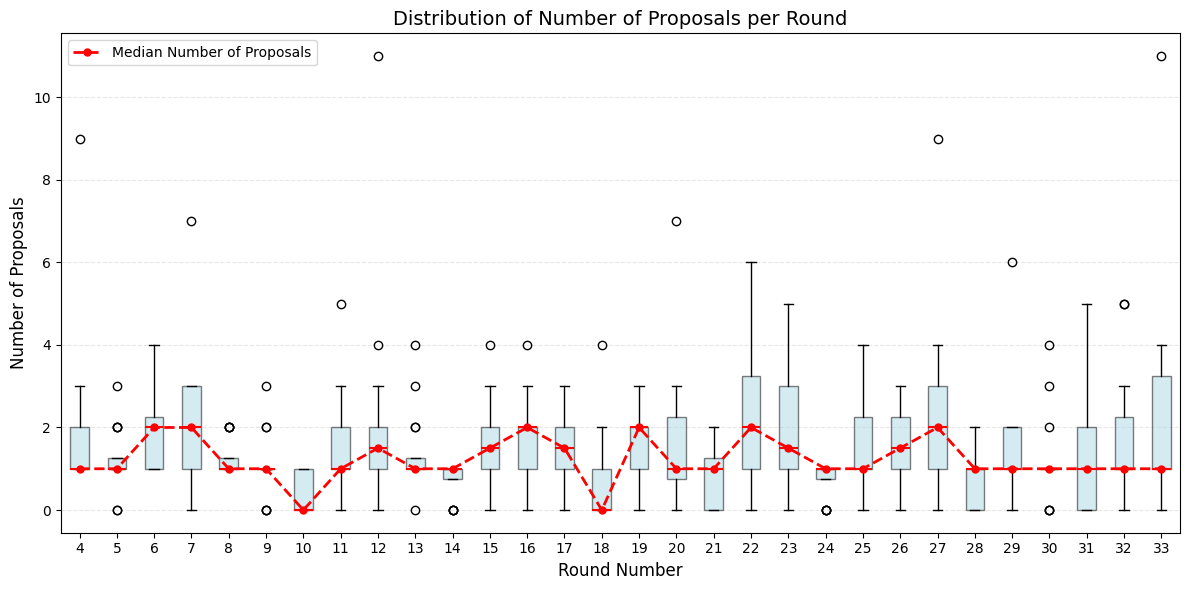

In [16]:
# Create list to store number of proposals for each round
proposal_counts = []
rounds = []

# Get number of proposals for each round
for i in range(4, 34):
    # Convert string representation of lists to actual lists and count lengths
    round_proposals = data[f'bargain_live.{i}.player.amount_proposed_list'].apply(lambda x: len(ast.literal_eval(x)))
    proposal_counts.append(round_proposals)
    rounds.append(i)

# Create figure
plt.figure(figsize=(12, 6))

# Create boxplot
plt.boxplot(proposal_counts, 
            patch_artist=True,  # Fill boxes with color
            boxprops=dict(facecolor='lightblue', alpha=0.5),
            medianprops=dict(color="red", linewidth=1.5))

# Calculate and plot median line
medians = [np.median(counts) for counts in proposal_counts]
plt.plot(range(1, len(medians) + 1), medians, 
         color='red', marker='o', linestyle='--', 
         linewidth=2, markersize=5, 
         label='Median Number of Proposals')

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Number of Proposals', fontsize=12)
plt.title('Distribution of Number of Proposals per Round', fontsize=14)

# Set x-axis labels to show round numbers
plt.xticks(range(1, len(rounds) + 1), rounds)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()

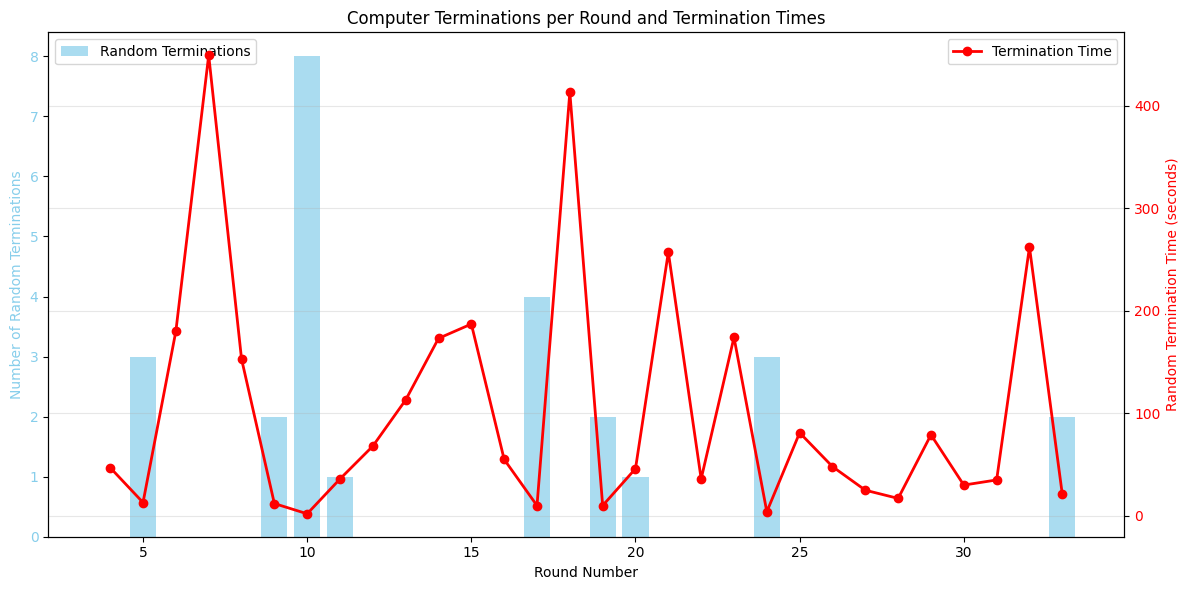

In [17]:
# Create lists to store counts
random_terminations = []
rounds = []

# Count random terminations for each round
for i in range(4, 34):
    counts = data[f'bargain_live.{i}.group.termination_mode'].value_counts()
    if 'Random_Termination' in counts:
        random_terminations.append(counts['Random_Termination'] / 2) 
    else:
        random_terminations.append(0)
    rounds.append(i)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot random terminations on primary axis
ax1.bar(rounds, random_terminations, color='skyblue', alpha=0.7)
ax1.set_xlabel('Round Number')
ax1.set_ylabel('Number of Random Terminations', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create secondary axis for termination times
ax2 = ax1.twinx()

# Get and plot termination times on secondary axis
termination_times = []
for i in range(4, 34):
    time = data[f'bargain_live.{i}.group.random_termination_time_current_round'].iloc[0]
    termination_times.append(time)

ax2.plot(rounds, termination_times, color='red', linewidth=2, marker='o', label='Termination Time')
ax2.set_ylabel('Random Termination Time (seconds)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Computer Terminations per Round and Termination Times')
plt.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(['Random Terminations'], loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [18]:
data["bargain_live.5.player.payoff"]

0     -1.80
1     -1.50
2     -1.50
3     20.40
4     29.25
5     32.80
6    -25.90
7     -1.80
8     12.95
9     -1.95
10    20.10
11   -22.30
12    24.55
13    -1.80
14    21.70
15    15.65
Name: bargain_live.5.player.payoff, dtype: float64

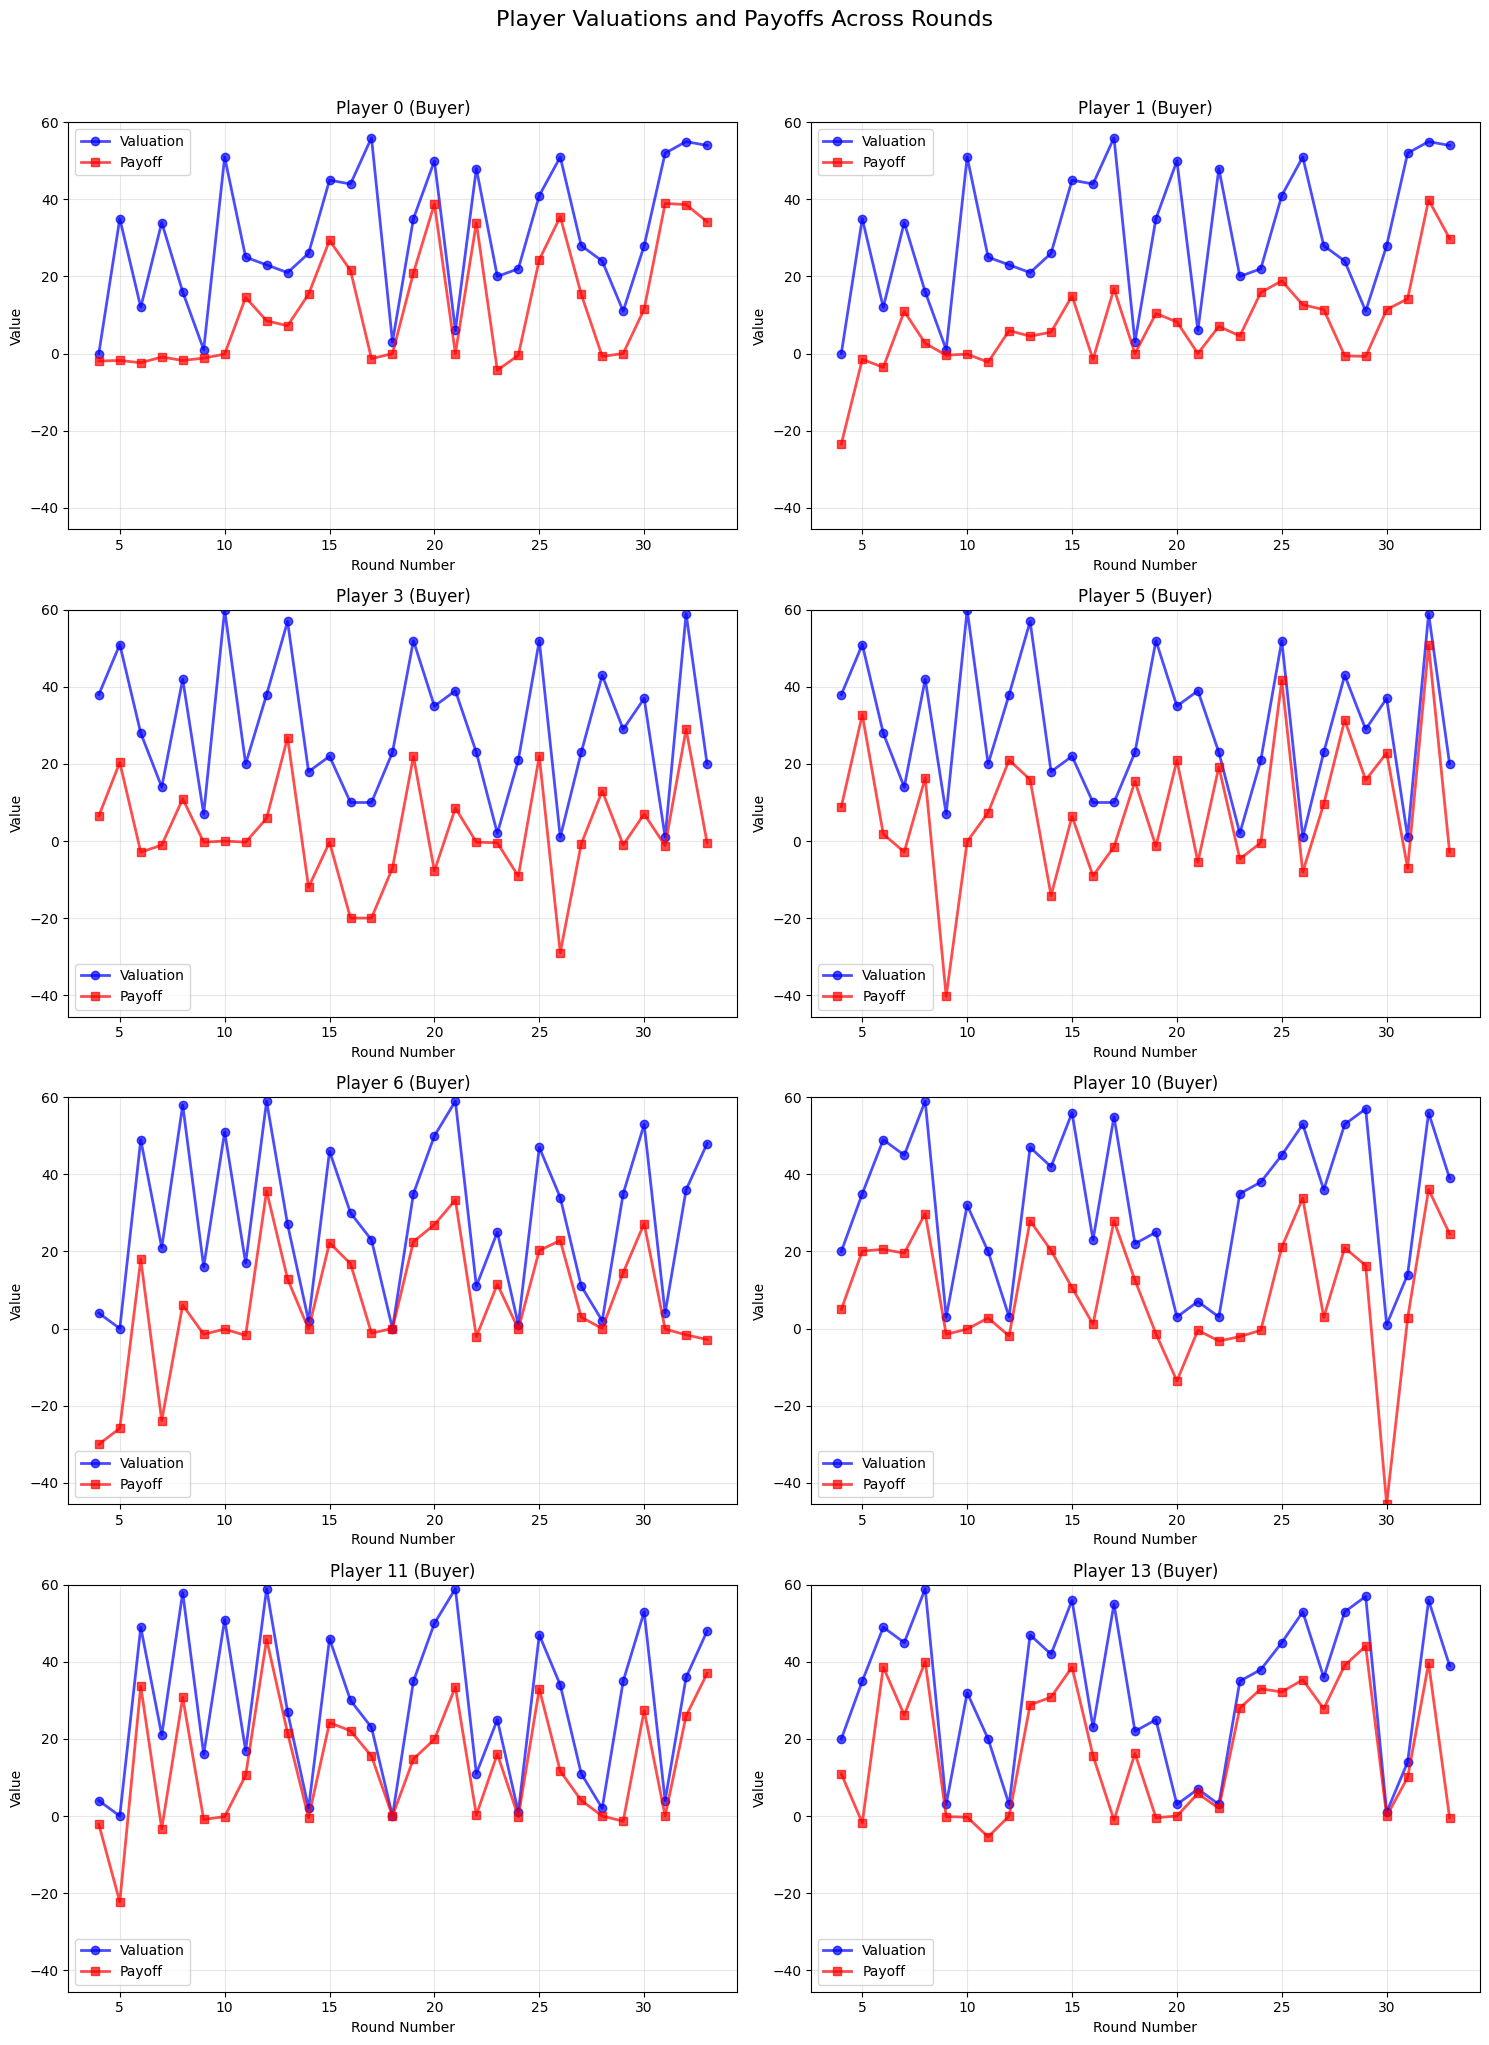

In [19]:
# Create figure with subplots in a 4x2 grid
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()  # Flatten to make iteration easier

# Get non-zero players from round 7 (as reference)
non_zero_players = data.index[data['bargain_live.7.player.valuation'] > 0]

# Determine global y-axis limits
all_valuations = []
all_payoffs = []
for player in non_zero_players:
    for round_num in range(4, 34):
        all_valuations.append(data.loc[player, f'bargain_live.{round_num}.player.valuation'])
        all_payoffs.append(data.loc[player, f'bargain_live.{round_num}.player.payoff'])

y_min = min(min(all_valuations), min(all_payoffs))
y_max = max(max(all_valuations), max(all_payoffs))

# For each player with non-zero valuations
for idx, player in enumerate(non_zero_players):
    # Get player's role
    player_role = data.loc[player, 'participant.role_in_game']
    
    # Get valuations and payoffs across rounds
    valuations = []
    payoffs = []
    for round_num in range(4, 34):
        val = data.loc[player, f'bargain_live.{round_num}.player.valuation']
        pay = data.loc[player, f'bargain_live.{round_num}.player.payoff']
        valuations.append(val)
        payoffs.append(pay)
    
    # Plot on corresponding subplot
    axes[idx].plot(range(4, 34), valuations, 
                  color='blue', linewidth=2, marker='o', 
                  label='Valuation', alpha=0.7)
    axes[idx].plot(range(4, 34), payoffs, 
                  color='red', linewidth=2, marker='s', 
                  label='Payoff', alpha=0.7)
    
    # Configure subplot
    axes[idx].set_xlabel('Round Number')
    axes[idx].set_ylabel('Value')
    axes[idx].set_title(f'Player {player} ({player_role})')
    axes[idx].set_ylim(y_min, y_max)  # Set consistent y-axis limits
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

# Add main title
fig.suptitle('Player Valuations and Payoffs Across Rounds', fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

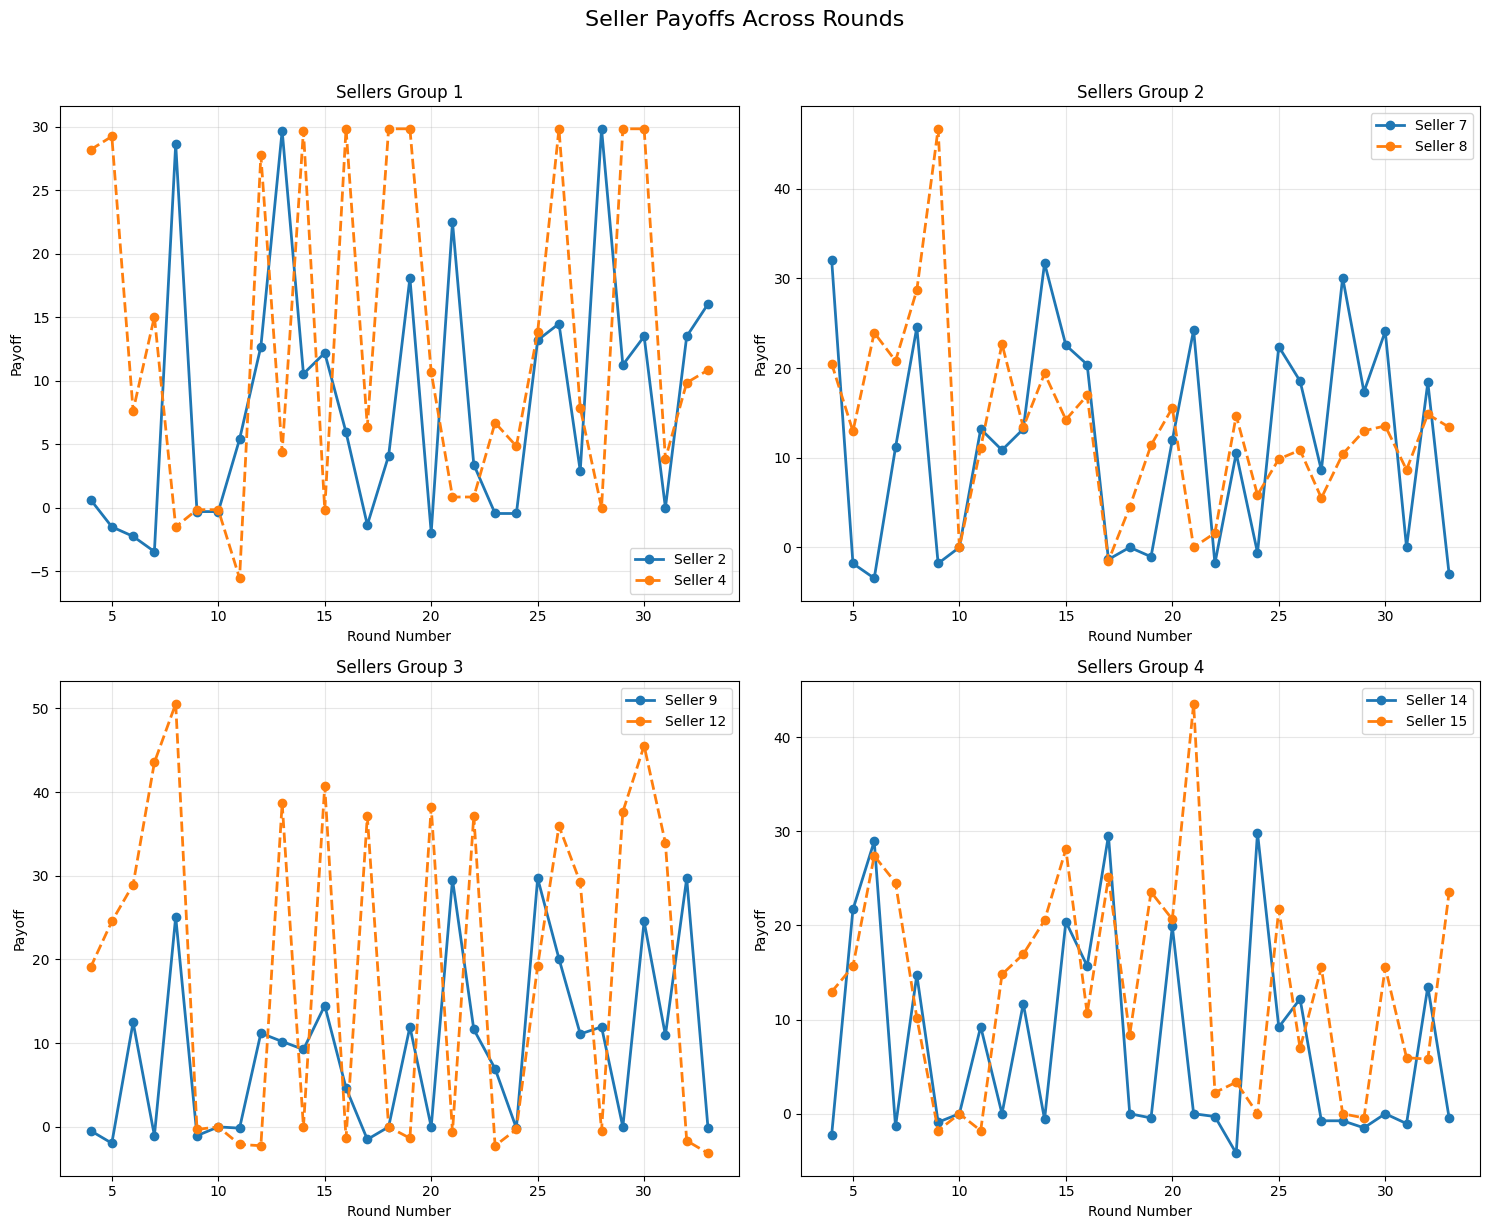

In [20]:
# Create figure with subplots in a 2x2 grid (4 plots for 8 sellers)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Flatten to make iteration easier

# Get all sellers
sellers = data[data['participant.role_in_game'] == 'Seller'].index

# Styles for each seller in a subplot
styles = [
    {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 2},    # Solid blue
    {'color': '#ff7f0e', 'linestyle': '--', 'linewidth': 2},   # Dashed orange
]

# For each subplot (pair of sellers)
for plot_idx in range(4):
    # Get the two sellers for this subplot
    seller1 = sellers[plot_idx * 2]
    seller2 = sellers[plot_idx * 2 + 1]
    
    # Get payoffs for both sellers
    for idx, seller in enumerate([seller1, seller2]):
        payoffs = []
        for round_num in range(4, 34):
            pay = data.loc[seller, f'bargain_live.{round_num}.player.payoff']
            payoffs.append(pay)
        
        # Plot with corresponding style
        style = styles[idx]
        axes[plot_idx].plot(range(4, 34), payoffs, 
                          marker='o', markersize=6,
                          label=f'Seller {seller}',
                          **style)
    
    # Configure subplot
    axes[plot_idx].set_xlabel('Round Number')
    axes[plot_idx].set_ylabel('Payoff')
    axes[plot_idx].set_title(f'Sellers Group {plot_idx + 1}')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()

# Add main title
fig.suptitle('Seller Payoffs Across Rounds', fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

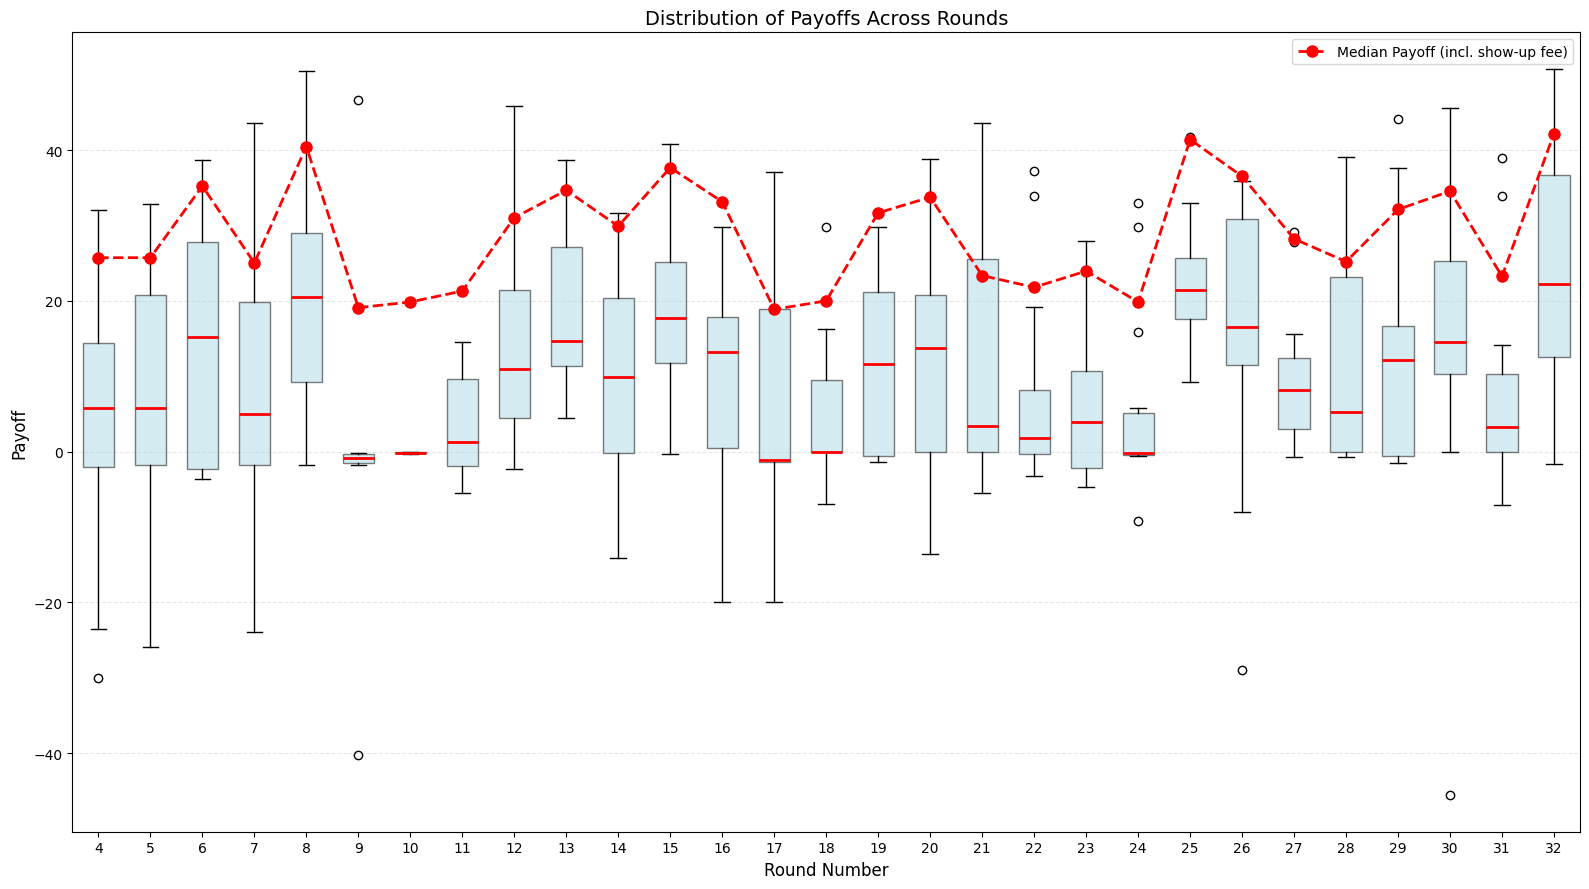

In [21]:
# Create list to store payoffs for each round
payoffs_excluding_fee = []
payoffs_including_fee = []

for i in range(4, 33):
    # Get all payoffs for the round, including terminated negotiations
    round_payoffs = data[f'bargain_live.{i}.player.payoff'].values
    payoffs_excluding_fee.append(round_payoffs)
    
    # Calculate median payoff including show-up fee
    payoffs_including_fee.append((data[f'bargain_live.{i}.player.payoff'] + 20).median())

# Create figure with PowerPoint-friendly dimensions
plt.figure(figsize=(16, 9))

# Create boxplot
plt.boxplot(payoffs_excluding_fee, widths=0.6,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.5),
           medianprops=dict(color="red", linewidth=2))

# Plot median payoff including show-up fee
plt.plot(range(1, 30), payoffs_including_fee, color='red', linestyle='--', 
         linewidth=2, marker='o', markersize=8,
         label='Median Payoff (incl. show-up fee)')

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Payoff', fontsize=12)
plt.title('Distribution of Payoffs Across Rounds', fontsize=14)

# Set x-axis labels
plt.xticks(range(1, 30), range(4, 33), fontsize=10)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add legend
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

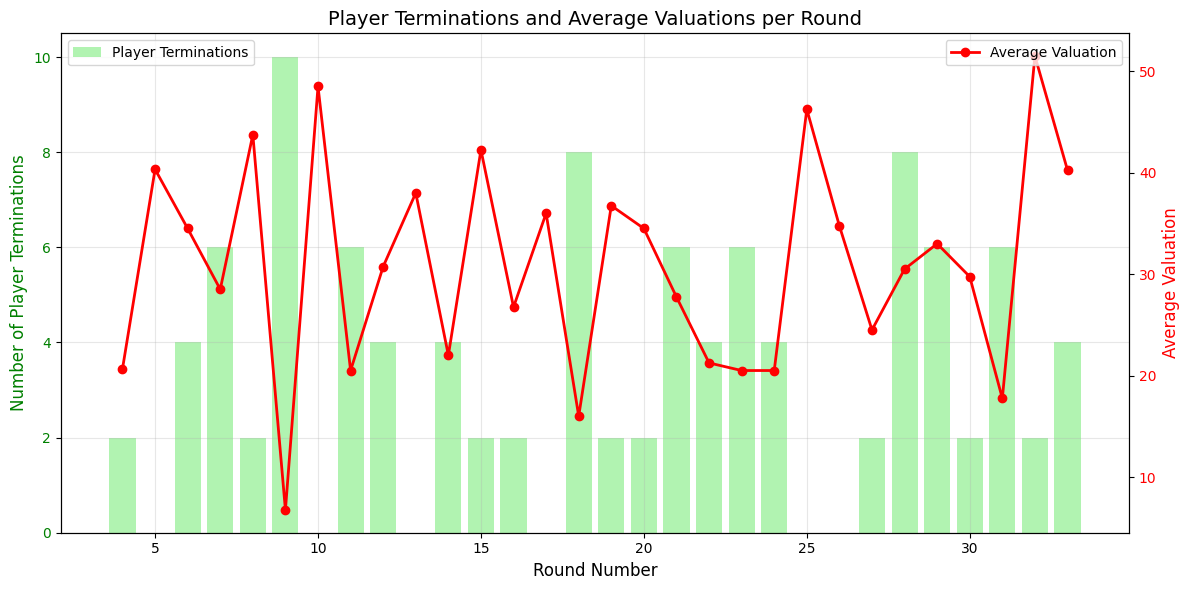

In [22]:
# Create lists to store counts and valuations
player_terminations = []
avg_valuations = []
rounds = []

# Count player terminations and calculate average valuations for each round
for i in range(4, 34):
    # Get termination counts
    counts = data[f'bargain_live.{i}.group.termination_mode'].value_counts()
    if 'Player' in counts:
        player_terminations.append(counts['Player']) 
    else:
        player_terminations.append(0)
    
    # Calculate average valuation for the round (excluding zeros)
    valuations = data[f'bargain_live.{i}.player.valuation']
    avg_val = valuations[valuations > 0].mean()
    avg_valuations.append(avg_val)
    
    rounds.append(i)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot terminations on primary axis
bars = ax1.bar(rounds, player_terminations, color='lightgreen', alpha=0.7)
ax1.set_xlabel('Round Number', fontsize=12)
ax1.set_ylabel('Number of Player Terminations', fontsize=12, color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Create secondary axis for average valuations
ax2 = ax1.twinx()
line = ax2.plot(rounds, avg_valuations, color='red', linewidth=2, marker='o', 
                label='Average Valuation')
ax2.set_ylabel('Average Valuation', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and grid
plt.title('Player Terminations and Average Valuations per Round', fontsize=14)
ax1.grid(True, alpha=0.3)

# Add legend
ax1.legend(['Player Terminations'], loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

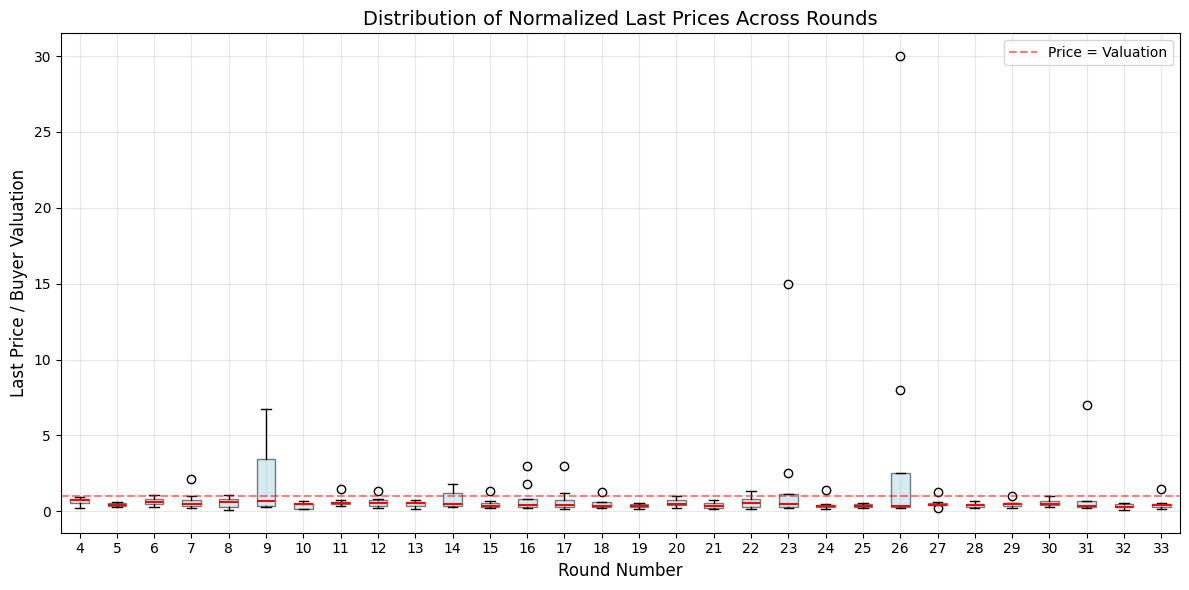

In [23]:
# Create lists to store normalized prices
normalized_prices = []
rounds = []

for round_num in range(4, 34):
    round_prices = []
    
    # Get buyers only
    buyers = data[data['participant.role_in_game'] == 'Buyer'].index
    
    for buyer in buyers:
        # Get buyer's valuation
        valuation = data.loc[buyer, f'bargain_live.{round_num}.player.valuation']
        
        if valuation > 0:  # Only consider active buyers
            # Get the list of proposed prices
            price_list_str = data.loc[buyer, f'bargain_live.{round_num}.player.amount_proposed_list']
            price_list = ast.literal_eval(price_list_str)
            
            if price_list:  # If there were any proposals
                last_price = price_list[-1]  # Get the last proposed price
                normalized_price = last_price / valuation
                round_prices.append(normalized_price)
    
    if round_prices:  # If we found any prices for this round
        normalized_prices.append(round_prices)
        rounds.append(round_num)

# Create the plot
plt.figure(figsize=(12, 6))

# Create boxplot
plt.boxplot(normalized_prices, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.5),
            medianprops=dict(color="red", linewidth=1.5))

# Add reference line at 1.0 (price equals valuation)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Price = Valuation')

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Last Price / Buyer Valuation', fontsize=12)
plt.title('Distribution of Normalized Last Prices Across Rounds', fontsize=14)

# Set x-axis labels to show round numbers
plt.xticks(range(1, len(rounds) + 1), rounds)

# Fix y-axis limits between 0 and 1
#plt.ylim(0, 1)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()

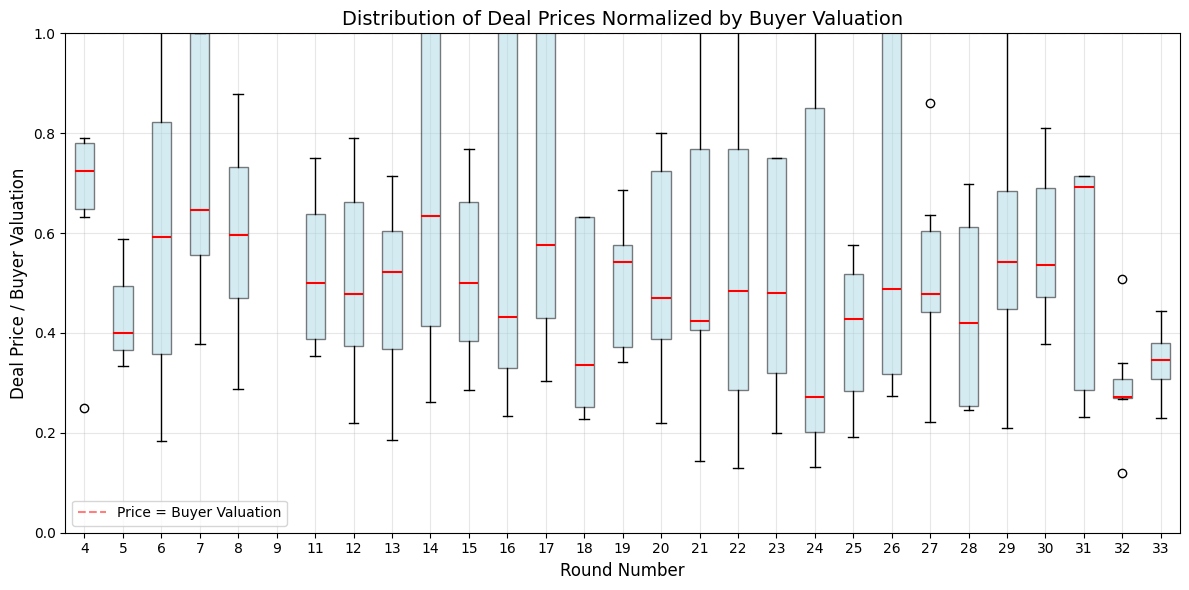


Summary Statistics for Deal Price / Buyer Valuation:
Mean: 1.258
Median: 0.500
Std Dev: 4.417


In [24]:
# Create lists to store normalized prices
normalized_prices = []
rounds = []

for round_num in range(4, 34):
    round_prices = []
    
    # Get all groups in this round
    groups = data[f'bargain_live.{round_num}.group.id_in_subsession'].unique()
    
    for group in groups:
        # Get the deal price for this group
        deal_price = data[data[f'bargain_live.{round_num}.group.id_in_subsession'] == group][f'bargain_live.{round_num}.group.deal_price'].iloc[0]
        
        if pd.notna(deal_price) and deal_price != 0:  # Only consider groups with valid deal prices
            # Find the buyer in this group
            buyer = data[(data['participant.role_in_game'] == 'Buyer') & 
                        (data[f'bargain_live.{round_num}.group.id_in_subsession'] == group)].index[0]
            
            # Get buyer's valuation
            buyer_valuation = data.loc[buyer, f'bargain_live.{round_num}.player.valuation']
            
            if buyer_valuation > 0:  # Only consider active buyers
                normalized_price = deal_price / buyer_valuation
                round_prices.append(normalized_price)
    
    if round_prices:  # If we found any prices for this round
        normalized_prices.append(round_prices)
        rounds.append(round_num)

# Create the plot
plt.figure(figsize=(12, 6))

# Create boxplot
plt.boxplot(normalized_prices, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.5),
            medianprops=dict(color="red", linewidth=1.5))

# Add reference line at 1.0 (price equals valuation)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Price = Buyer Valuation')

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Deal Price / Buyer Valuation', fontsize=12)
plt.title('Distribution of Deal Prices Normalized by Buyer Valuation', fontsize=14)

# Set x-axis labels to show round numbers
plt.xticks(range(1, len(rounds) + 1), rounds)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

plt.ylim(0, 1)

# Adjust layout
plt.tight_layout()
plt.show()

# Print summary statistics
all_normalized_prices = [price for round_prices in normalized_prices for price in round_prices]
print("\nSummary Statistics for Deal Price / Buyer Valuation:")
print(f"Mean: {np.mean(all_normalized_prices):.3f}")
print(f"Median: {np.median(all_normalized_prices):.3f}")
print(f"Std Dev: {np.std(all_normalized_prices):.3f}")

I know want to know if buyers make offers earlier if they have a higher valuation. So I want to make a plot with the first offer time on the y-axis and the valuation on the x-axis. I do this for buyers


Overall Statistics:
Total negotiations: 240.0
Accepted: 162.0 (67.5%)
Player Terminations: 52.0 (21.7%)
Random Terminations: 26.0 (10.8%)


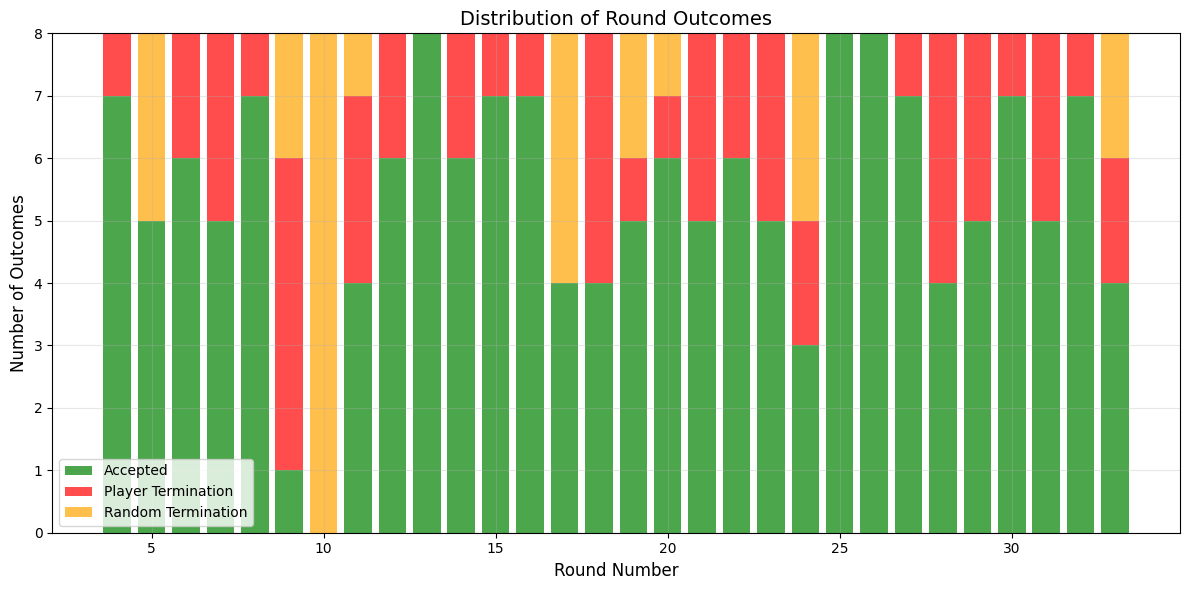

In [25]:
# Create lists to store counts
accepted_counts = []
player_termination_counts = []
random_termination_counts = []
rounds = []

# Count outcomes for each round
for i in range(4, 34):
    counts = data[f'bargain_live.{i}.group.termination_mode'].value_counts()
    
    # Count terminations (divide by 2 since each outcome appears for both players)
    player_term = counts.get('Player', 0) / 2
    random_term = counts.get('Random_Termination', 0) / 2
    
    # Acceptances are all remaining negotiations (total of 8 pairs per round)
    accepted = 8 - (player_term + random_term)
    
    accepted_counts.append(accepted)
    player_termination_counts.append(player_term)
    random_termination_counts.append(random_term)
    rounds.append(i)

# Create stacked bar plot
plt.figure(figsize=(12, 6))

# Create stacked bars
plt.bar(rounds, accepted_counts, label='Accepted', color='green', alpha=0.7)
plt.bar(rounds, player_termination_counts, bottom=accepted_counts, 
        label='Player Termination', color='red', alpha=0.7)
plt.bar(rounds, random_termination_counts, 
        bottom=[sum(x) for x in zip(accepted_counts, player_termination_counts)],
        label='Random Termination', color='orange', alpha=0.7)

# Add labels and title
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Number of Outcomes', fontsize=12)
plt.title('Distribution of Round Outcomes', fontsize=14)

# Add grid
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

# Calculate and print overall statistics
total_rounds = len(rounds)
total_accepted = sum(accepted_counts)
total_player_term = sum(player_termination_counts)
total_random_term = sum(random_termination_counts)
total_negotiations = total_accepted + total_player_term + total_random_term

print("\nOverall Statistics:")
print(f"Total negotiations: {total_negotiations}")
print(f"Accepted: {total_accepted} ({total_accepted/total_negotiations*100:.1f}%)")
print(f"Player Terminations: {total_player_term} ({total_player_term/total_negotiations*100:.1f}%)")
print(f"Random Terminations: {total_random_term} ({total_random_term/total_negotiations*100:.1f}%)")

plt.tight_layout()
plt.show()

# Debugging: I had some concerns raised during the experiment

In [26]:
data["bargain_live.5.player.role"]

0      Buyer
1      Buyer
2     Seller
3      Buyer
4     Seller
5      Buyer
6      Buyer
7     Seller
8     Seller
9     Seller
10     Buyer
11     Buyer
12    Seller
13     Buyer
14    Seller
15    Seller
Name: bargain_live.5.player.role, dtype: object

In [27]:
# Get all participant labels
participants = data["participant.label"].unique()

# Check roles across rounds for each participant
for participant in participants:
    participant_data = data[data["participant.label"] == participant]
    roles = []
    
    # Collect roles from all rounds
    for round_num in range(4, 34):
        role = participant_data[f'bargain_live.{round_num}.player.role'].iloc[0]
        roles.append(role)
    
    # Check if all roles are the same
    is_consistent = all(role == roles[0] for role in roles)
    
    print(f"Participant {participant}:")
    print(f"Initial role: {roles[0]}")
    print(f"Role consistent across all rounds: {is_consistent}")
    if not is_consistent:
        print("WARNING: Roles changed during the experiment!")
    print("-" * 50)

Participant GK032w6A:
Initial role: Buyer
Role consistent across all rounds: True
--------------------------------------------------
Participant xok4JQIx:
Initial role: Buyer
Role consistent across all rounds: True
--------------------------------------------------
Participant HiSs6lVk:
Initial role: Seller
Role consistent across all rounds: True
--------------------------------------------------
Participant u874W2aM:
Initial role: Buyer
Role consistent across all rounds: True
--------------------------------------------------
Participant QfM0ZFNw:
Initial role: Seller
Role consistent across all rounds: True
--------------------------------------------------
Participant nxmyIOpw:
Initial role: Buyer
Role consistent across all rounds: True
--------------------------------------------------
Participant ezgUFdcT:
Initial role: Buyer
Role consistent across all rounds: True
--------------------------------------------------
Participant C2br7Phv:
Initial role: Seller
Role consistent across a

Participant GK032w6A:
Random round: 24
Payoff in random round: 19.55
--------------------------------------------------
Participant xok4JQIx:
Random round: 4
Payoff in random round: -3.5
--------------------------------------------------
Participant HiSs6lVk:
Random round: 9
Payoff in random round: 19.7
--------------------------------------------------
Participant u874W2aM:
Random round: 7
Payoff in random round: 18.95
--------------------------------------------------
Participant QfM0ZFNw:
Random round: 32
Payoff in random round: 29.85
--------------------------------------------------
Participant nxmyIOpw:
Random round: 10
Payoff in random round: 19.85
--------------------------------------------------
Participant ezgUFdcT:
Random round: 32
Payoff in random round: 18.35
--------------------------------------------------
Participant C2br7Phv:
Random round: 4
Payoff in random round: 52.1
--------------------------------------------------
Participant 3yK1oFK6:
Random round: 25
Payoff i

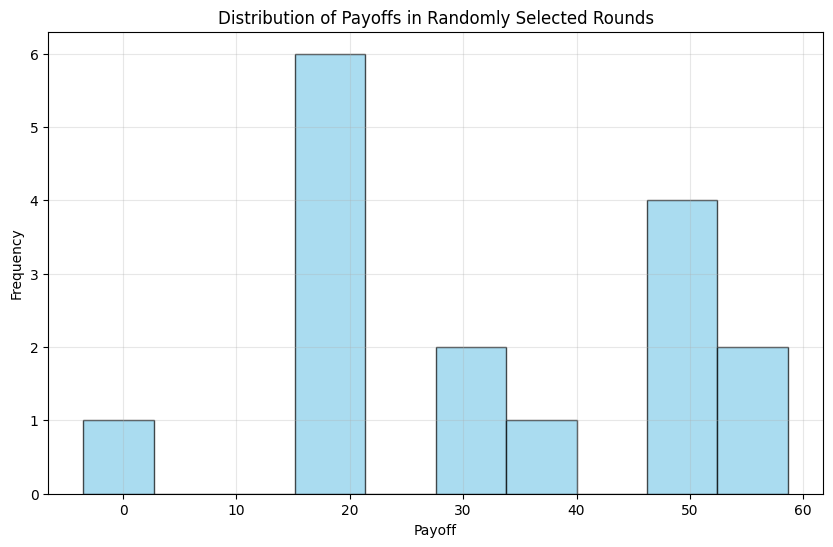

In [28]:
# Get random rounds and corresponding payoffs
random_round_payoffs = []
for idx, participant in enumerate(data["participant.label"]):
    random_round = data["participant.random_round"].iloc[idx]
    payoff = data[f'bargain_live.{random_round}.player.payoff'].iloc[idx] + 20
    
    print(f"Participant {participant}:")
    print(f"Random round: {random_round}")
    print(f"Payoff in random round: {payoff}")
    print("-" * 50)
    
    random_round_payoffs.append(payoff)

# Calculate some summary statistics
print("\nSummary Statistics:")
print(f"Average payoff: {np.mean(random_round_payoffs):.2f}")
print(f"Median payoff: {np.median(random_round_payoffs):.2f}")
print(f"Min payoff: {min(random_round_payoffs):.2f}")
print(f"Max payoff: {max(random_round_payoffs):.2f}")

# Create a histogram of the payoffs
plt.figure(figsize=(10, 6))
plt.hist(random_round_payoffs, bins=10, color='skyblue', alpha=0.7, edgecolor='black')
plt.xlabel('Payoff')
plt.ylabel('Frequency')
plt.title('Distribution of Payoffs in Randomly Selected Rounds')
plt.grid(True, alpha=0.3)
plt.show()